<a href="https://colab.research.google.com/github/Vaishnavi644/Fake-job-Posting-detection-Project/blob/main/Fake_Job_Posting_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load Dataset

In [ ]:
df = pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [ ]:
print(df.shape)
df.info()

(17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  obje

In [ ]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

## Statistical Summary

In [ ]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


## Missing Values

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


## Missing Value Percentage

In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values(ascending=False)

,0
salary_range,83.959732
department,64.580537
required_education,45.329978
benefits,40.335570
required_experience,39.429530
function,36.101790
industry,27.421700
employment_type,19.412752
company_profile,18.501119
requirements,15.078300


## Missing Value Summary Table

In [ ]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing_data = missing_data.sort_values(
    by="Percentage",
    ascending=False
)

missing_data

,Missing Values,Percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


##Missing Value Heatmap

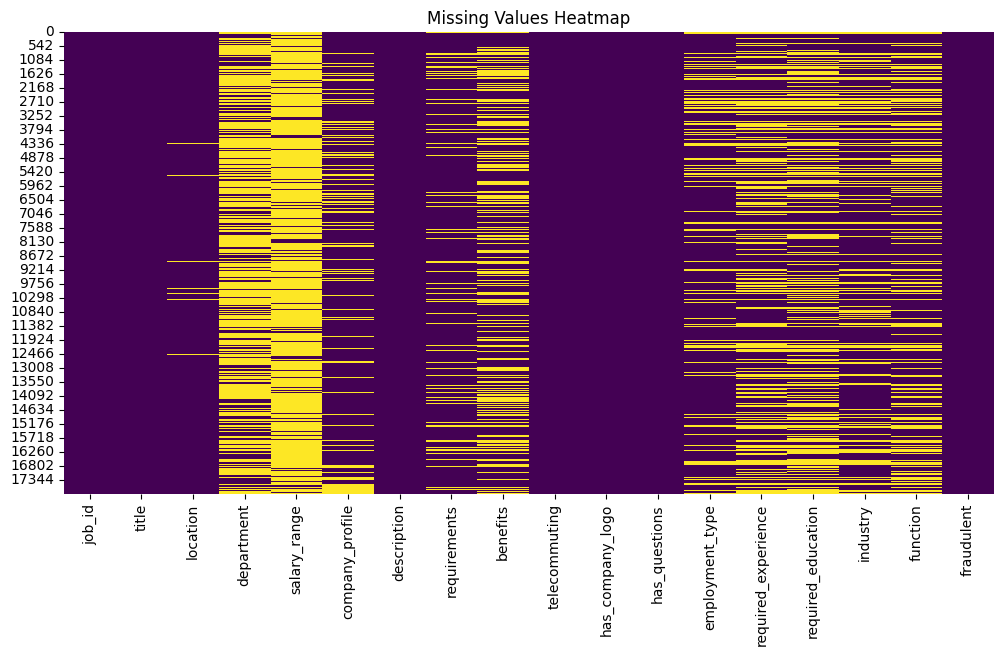

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

## Duplicate Rows

In [ ]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


##Remove Duplicate Rows (if any)

In [ ]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (17880, 18)


## Target Variable Distribution

In [ ]:
fraud_count = df['fraudulent'].value_counts()
fraud_percentage = df['fraudulent'].value_counts(normalize=True) * 100

print(fraud_count)
print(fraud_percentage)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


## Target Count Plot

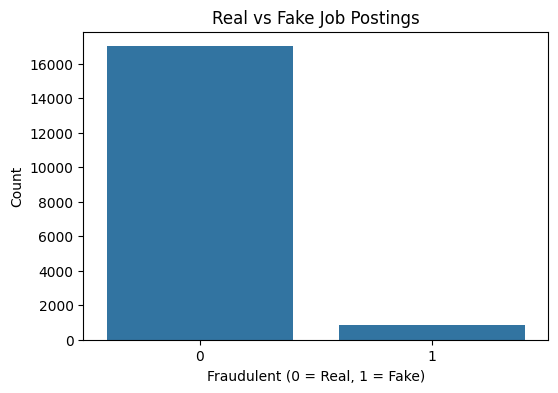

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="fraudulent",
    data=df
)

plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Count")

plt.show()

## Pie Chart

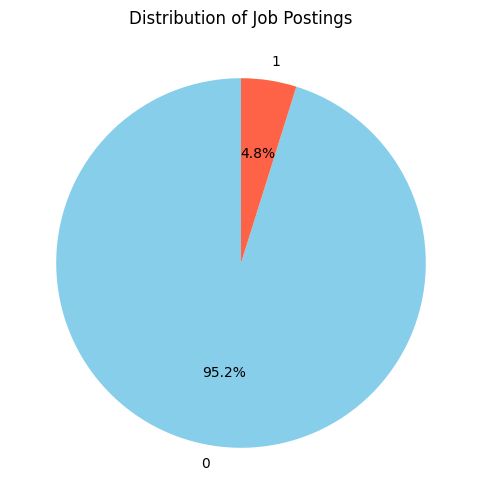

In [ ]:
plt.figure(figsize=(6,6))

df["fraudulent"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","tomato"]
)

plt.ylabel("")
plt.title("Distribution of Job Postings")

plt.show()

## Data Types

In [ ]:
df.dtypes

,0
job_id,int64
title,object
location,object
department,object
salary_range,object
company_profile,object
description,object
requirements,object
benefits,object
telecommuting,int64


## Numerical Columns

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print(numerical_columns)

['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']


## Categorical Columns

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print(categorical_columns)

['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


## Number of Unique Values

In [ ]:
for column in categorical_columns:

    print("="*60)

    print(column)

    print("Unique Values:", df[column].nunique())

title
Unique Values: 11231
location
Unique Values: 3105
department
Unique Values: 1337
salary_range
Unique Values: 874
company_profile
Unique Values: 1709
description
Unique Values: 14801
requirements
Unique Values: 11967
benefits
Unique Values: 6204
employment_type
Unique Values: 5
required_experience
Unique Values: 7
required_education
Unique Values: 13
industry
Unique Values: 131
function
Unique Values: 37


## Missing Company Profile Analysis

In [ ]:
df["has_company_profile"] = df["company_profile"].notnull().astype(int)

pd.crosstab(
    df["has_company_profile"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,0,1
has_company_profile,,
0,0.822551,0.177449
1,0.980854,0.019146


## Company Logo Analysis

In [ ]:
pd.crosstab(
    df["has_company_logo"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,0,1
has_company_logo,,
0,0.840710,0.159290
1,0.980098,0.019902


## Has Questions Analysis

In [ ]:
pd.crosstab(
    df["has_questions"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,0,1
has_questions,,
0,0.932218,0.067782
1,0.971565,0.028435


## Telecommuting Analysis

In [ ]:
pd.crosstab(
    df["telecommuting"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,0,1
telecommuting,,
0,0.953135,0.046865
1,0.916558,0.083442


## Description Length

In [ ]:
df["description"] = df["description"].fillna("")

df["desc_length"] = df["description"].apply(len)

df.groupby("fraudulent")["desc_length"].mean()

,desc_length
fraudulent,
0,1221.219701
1,1154.834873


## Description Length Boxplot

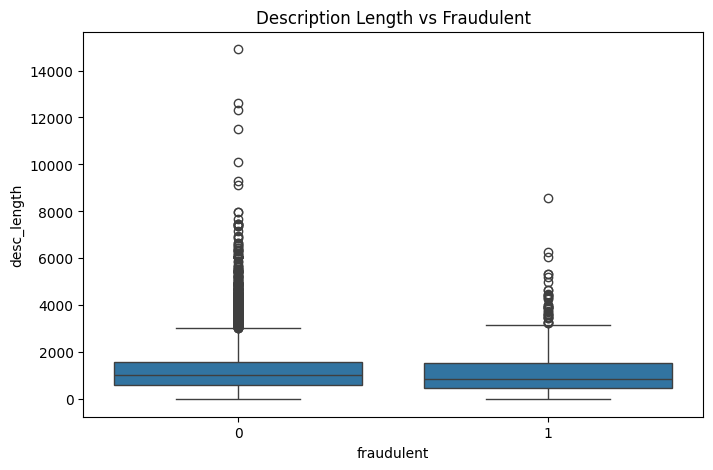

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="desc_length"
)

plt.title("Description Length vs Fraudulent")

plt.show()

## Employment Type

In [ ]:
df["employment_type"].value_counts(dropna=False)

,count
employment_type,
Full-time,11620
NaN,3471
Contract,1524
Part-time,797
Temporary,241
Other,227


## Experience

In [ ]:
df["required_experience"].value_counts(dropna=False)

,count
required_experience,
NaN,7050
Mid-Senior level,3809
Entry level,2697
Associate,2297
Not Applicable,1116
Director,389
Internship,381
Executive,141


## Education

In [ ]:
df["required_education"].value_counts(dropna=False)

,count
required_education,
NaN,8105
Bachelor's Degree,5145
High School or equivalent,2080
Unspecified,1397
Master's Degree,416
Associate Degree,274
Certification,170
Some College Coursework Completed,102
Professional,74


## Industry

In [ ]:
df["industry"].value_counts(dropna=False).head(20)

,count
industry,
NaN,4903
Information Technology and Services,1734
Computer Software,1376
Internet,1062
Marketing and Advertising,828
Education Management,822
Financial Services,779
Hospital & Health Care,497
Consumer Services,358


## Function

In [ ]:
df["function"].value_counts(dropna=False).head(20)

,count
function,
NaN,6455
Information Technology,1749
Sales,1468
Engineering,1348
Customer Service,1229
Marketing,830
Administrative,630
Design,340
Health Care Provider,338


## Correlation Heatmap

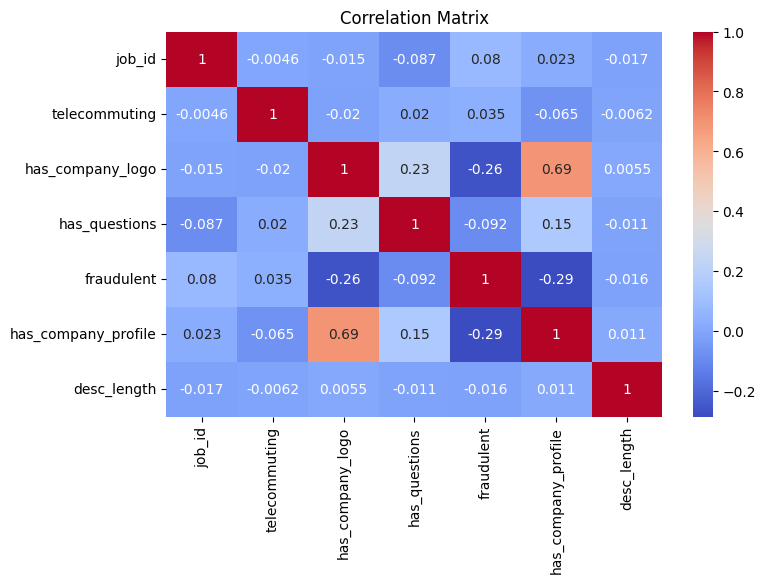

In [ ]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Exploratory Data Analysis Summary

In [ ]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("Dataset Shape :", df.shape)
print("Total Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())

print("\nReal Jobs :", df["fraudulent"].value_counts()[0])
print("Fake Jobs :", df["fraudulent"].value_counts()[1])

DATASET SUMMARY
Dataset Shape : (17880, 20)
Total Missing Values : 70105
Duplicate Rows : 0

Real Jobs : 17014
Fake Jobs : 866


# Data Cleaning and Feature Engineering

In this section, the dataset is prepared for machine learning by handling missing values, removing unnecessary features, and selecting relevant attributes. Multiple text-based features are combined into a single column, and text preprocessing techniques such as lowercasing, punctuation removal, stopword removal, and lemmatization are applied to improve the quality of the textual data.

## Creating a Copy of Dataset

In [ ]:
df_clean = df.copy()

print("Copy Created Successfully!")

Copy Created Successfully!


##Check Missing Values Again

In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


In [ ]:
df_clean.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'has_company_profile', 'desc_length'],
      dtype='object')

## Fill Missing Values

In [ ]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    df_clean[column] = df_clean[column].fillna("")

##Categorical Columns

In [ ]:
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "department",
    "salary_range",
    "location"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna("Unknown")

## Verify Missing Values

In [ ]:
df_clean.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


## Select Useful Features

In [ ]:
selected_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent"
]

df_clean = df_clean[selected_columns]

In [ ]:
df_clean.head()

,title,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,telecommuting,has_company_logo,has_questions,fraudulent
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,Other,Internship,Unknown,Unknown,Marketing,0,1,0,0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,1,0,0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,Unknown,Unknown,Unknown,Unknown,Unknown,0,1,0,0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,1,0,0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1,1,0


## Combine text Columns

In [ ]:
df_clean["text"] = (
    df_clean["title"] + " " +
    df_clean["company_profile"] + " " +
    df_clean["description"] + " " +
    df_clean["requirements"] + " " +
    df_clean["benefits"]
)

In [ ]:
df_clean["text"].head()

,text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


## Import NLP Libraries

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## Download Required NLTK Resources

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##Initialize Stopwords and Lemmatizer

In [ ]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

## Create Text Cleaning Function

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = text.split()

    text = [
        lemmatizer.lemmatize(word)
        for word in text
        if word not in stop_words
    ]

    return " ".join(text)

## Apply Cleaning

In [ ]:
df_clean["clean_text"] = df_clean["text"].apply(clean_text)

## View Cleaned Text

In [ ]:
df_clean[["text","clean_text"]].head()

,text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


## Remove Empty Rows

In [ ]:
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""]

## Final Dataset

In [ ]:
df_clean.head()

,title,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,telecommuting,has_company_logo,has_questions,fraudulent,text,clean_text
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,Other,Internship,Unknown,Unknown,Marketing,0,1,0,0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,1,0,0,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,Unknown,Unknown,Unknown,Unknown,Unknown,0,1,0,0,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,1,0,0,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1,1,0,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


##Dataset Shape

In [ ]:
print(df_clean.shape)

(17880, 16)


##Save Clean Dataset

In [ ]:
df_clean.to_csv("clean_fake_job_postings.csv", index=False)

#  Text Vectorization and Machine Learning

This section converts the cleaned textual data into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique. The dataset is then divided into training and testing sets, and multiple machine learning models are trained, including Logistic Regression, Multinomial Naive Bayes, Decision Tree, and Random Forest. The models are evaluated using multiple performance metrics to determine the most effective classifier for detecting fraudulent job postings.

## Select Features and Target

In [ ]:
# Features (X)
X = df_clean["clean_text"]

# Target (y)
y = df_clean["fraudulent"]

## Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples: (14304,)
Testing Samples : (3576,)


## Apply TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

## Check Shape

In [ ]:
print("Training Matrix :", X_train_tfidf.shape)
print("Testing Matrix :", X_test_tfidf.shape)

Training Matrix : (14304, 10000)
Testing Matrix : (3576, 10000)


##Import Models

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

## Import Evaluation Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

## Logistic Regression Results

In [ ]:
print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision :", precision_score(y_test, lr_predictions))
print("Recall :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

Accuracy : 0.9731543624161074
Precision : 1.0
Recall : 0.44508670520231214
F1 Score : 0.616


## Classification Report

In [ ]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.45      0.62       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



## Confusion Matrix

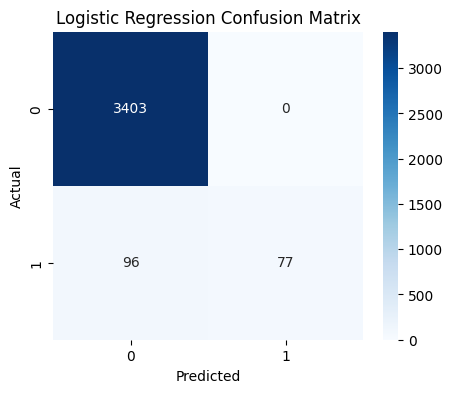

In [ ]:
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Multinomial Naive Bayes

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

## Naive Bayes Results

In [ ]:
print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision :", precision_score(y_test, nb_predictions))
print("Recall :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

Accuracy : 0.9611297539149888
Precision : 0.6808510638297872
Recall : 0.3699421965317919
F1 Score : 0.4794007490636704


## Classification Report

In [ ]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3403
           1       0.68      0.37      0.48       173

    accuracy                           0.96      3576
   macro avg       0.82      0.68      0.73      3576
weighted avg       0.95      0.96      0.96      3576



## Confusion Matrix

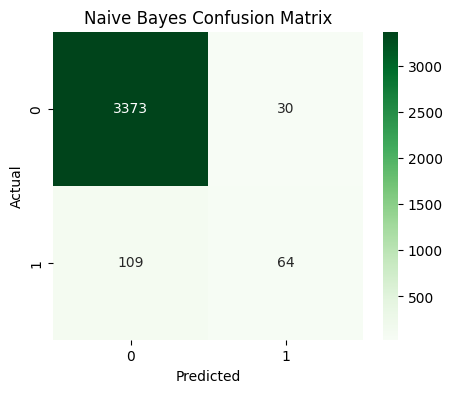

In [ ]:

cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

## Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_tfidf,
    y_train
)

dt_predictions = dt_model.predict(
    X_test_tfidf
)

## Decision Tree Results

In [ ]:
print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision :", precision_score(y_test, dt_predictions))
print("Recall :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))

Accuracy : 0.9751118568232662
Precision : 0.7413793103448276
Recall : 0.7456647398843931
F1 Score : 0.7435158501440923


## Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_tfidf
)

## Random Forest Results

In [ ]:
print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision :", precision_score(y_test, rf_predictions))
print("Recall :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))

Accuracy : 0.9829418344519015
Precision : 0.9912280701754386
Recall : 0.653179190751445
F1 Score : 0.7874564459930313


## Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, nb_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, nb_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, nb_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.982942,0.991228,0.653179,0.787456
2,Decision Tree,0.975112,0.741379,0.745665,0.743516
0,Logistic Regression,0.973154,1.000000,0.445087,0.616000
1,Naive Bayes,0.961130,0.680851,0.369942,0.479401


### Model Comparison Analysis

Four machine learning models were evaluated in this project:

- Logistic Regression
- Naive Bayes
- Decision Tree
- Random Forest

The models were compared using Accuracy, Precision, Recall, and F1 Score.

Among the baseline models, Random Forest achieved the best overall performance with the highest F1 Score and a good balance between Precision and Recall.

To further improve the results, Logistic Regression was optimized using GridSearchCV for hyperparameter tuning. After tuning, the optimized Logistic Regression achieved higher Accuracy, Recall, and F1 Score than the baseline Random Forest model.

Therefore, the tuned Logistic Regression was selected as the final model for the prediction system because it provided the best overall balance between correctly identifying fraudulent job postings and minimizing classification errors.

## Best Model

In [ ]:
best_model = results.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.982942,0.991228,0.653179,0.787456
2,Decision Tree,0.975112,0.741379,0.745665,0.743516
0,Logistic Regression,0.973154,1.000000,0.445087,0.616000
1,Naive Bayes,0.961130,0.680851,0.369942,0.479401


# Advanced Model Evaluation

To further improve model reliability, advanced evaluation techniques are applied. Cross-validation provides a more robust estimate of model performance, while GridSearchCV is used to identify the best hyperparameters for the Logistic Regression model.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

## Cross Validation

Cross-validation divides the training dataset into multiple folds and evaluates the model several times. This provides a more reliable estimate of model performance than a single train-test split.

In [ ]:
cv_scores = cross_val_score(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage F1 Score:", round(cv_scores.mean(), 4))

Cross Validation Scores:
[0.57731959 0.56852792 0.53403141 0.55670103 0.53968254]

Average F1 Score: 0.5553


## Hyperparameter Tuning using GridSearchCV

GridSearchCV tests different combinations of hyperparameters to determine the configuration that produces the best model performance.

In [ ]:
param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

###Create Grid Search

In [ ]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

### Train Grid Search

In [ ]:
grid_search.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

### Best Parameters

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 10, 'solver': 'liblinear'}

Best Cross Validation F1 Score:
0.7854


### Use the Best Model

In [ ]:
best_lr = grid_search.best_estimator_

## Prediction Function

In [ ]:
def predict_job_posting(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = best_lr.predict(vector)[0]

    if prediction == 0:
        return "Real Job Posting"

    else:
        return "Fake Job Posting"

## Test Prediction

In [ ]:
sample = """
We are looking for an experienced Python Developer.
The candidate should have knowledge of Django,
Machine Learning, SQL and Git.
"""

print(predict_job_posting(sample))

Real Job Posting


###Make Predictions

In [ ]:
best_predictions = best_lr.predict(
    X_test_tfidf
)

###Evaluate the Tuned Model

In [ ]:
print("Accuracy :", accuracy_score(y_test, best_predictions))
print("Precision:", precision_score(y_test, best_predictions))
print("Recall   :", recall_score(y_test, best_predictions))
print("F1 Score :", f1_score(y_test, best_predictions))

Accuracy : 0.9848993288590604
Precision: 0.983739837398374
Recall   : 0.6994219653179191
F1 Score : 0.8175675675675675


### Classification Report

In [ ]:
print(classification_report(
    y_test,
    best_predictions
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.98      0.70      0.82       173

    accuracy                           0.98      3576
   macro avg       0.98      0.85      0.90      3576
weighted avg       0.98      0.98      0.98      3576



### Model Interpretation

In [ ]:
feature_names = tfidf.get_feature_names_out()

coefficients = best_lr.coef_[0]

important_words = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

important_words = important_words.sort_values(
    by="Coefficient",
    ascending=False
)

important_words.head(20)

,Word,Coefficient
5119,link url,8.835226
5118,link,5.189326
5696,money,5.059721
520,aptitude staffing,4.989672
519,aptitude,4.839175
2765,earn,4.814124
111,accountant,4.688616
4185,high school,4.681643
7247,receptionist,4.319362
6482,phone,4.298509


In [ ]:
important_words.tail(20)

,Word,Coefficient
2103,custom,-2.674683
4084,hardware,-2.677396
8548,strong,-2.762644
9652,web,-2.812615
7841,search,-2.818789
9314,university,-2.834512
1128,ca,-2.880670
286,agency,-2.982523
5849,new,-3.075826
4583,installation,-3.087315


###  Model Interpretation

The final Logistic Regression model makes predictions by assigning a weight (coefficient) to every word generated by the TF-IDF vectorizer.

- Words with large positive coefficients increase the probability that a job posting is classified as fraudulent.
- Words with large negative coefficients increase the probability that a job posting is classified as genuine.

By examining the most influential words, we can better understand why the model predicts a job posting as fake or legitimate. This improves the transparency and interpretability of the machine learning system.

### Confusion Matrix

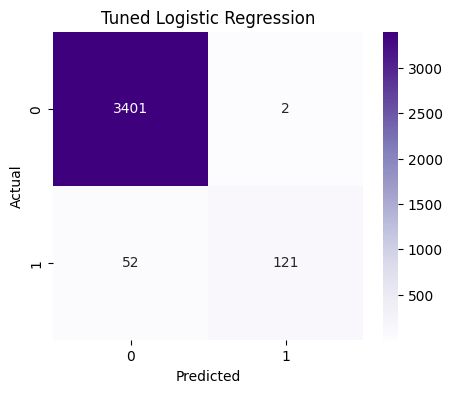

In [ ]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Tuned Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Save the Best Model

In [ ]:
import pickle

pickle.dump(
    best_lr,
    open("best_fake_job_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl", "wb")
)

print("Final optimized model saved successfully!")

Final optimized model saved successfully!


### Preprocessing Technique Comparison

Two text vectorization techniques were evaluated in this project:

- TF-IDF Vectorizer
- CountVectorizer

### Performance Comparison

| Technique | Accuracy | F1 Score |
|-----------|---------:|---------:|
| TF-IDF | 97.31% | 0.6160 |
| CountVectorizer | 98.55% | 0.8395 |

The purpose of this experiment was to analyze the impact of different text vectorization techniques on model performance.

Based on the experimental results, CountVectorizer achieved higher Accuracy and F1 Score than TF-IDF for this dataset. This indicates that CountVectorizer represented the textual information more effectively for the Fake Job Posting Detection task.

This comparison was performed as an additional preprocessing experiment to evaluate the effect of different text vectorization techniques.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
count_vectorizer = CountVectorizer(max_features=5000)

X_count = count_vectorizer.fit_transform(df_clean["clean_text"])

In [ ]:
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(
    X_count,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
count_lr = LogisticRegression(max_iter=1000)

count_lr.fit(
    X_train_count,
    y_train_count
)

LogisticRegression(max_iter=1000)

In [ ]:
count_predictions = count_lr.predict(X_test_count)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("CountVectorizer + Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test_count, count_predictions))
print("Precision:", precision_score(y_test_count, count_predictions))
print("Recall   :", recall_score(y_test_count, count_predictions))
print("F1 Score :", f1_score(y_test_count, count_predictions))

CountVectorizer + Logistic Regression Performance
Accuracy : 0.9854586129753915
Precision: 0.9006622516556292
Recall   : 0.7861271676300579
F1 Score : 0.8395061728395061


In [ ]:
comparison = pd.DataFrame({
    "Technique": ["TF-IDF", "CountVectorizer"],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test_count, count_predictions)
    ],
    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test_count, count_predictions)
    ],
    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test_count, count_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test_count, count_predictions)
    ]
})

comparison

,Technique,Accuracy,Precision,Recall,F1 Score
0,TF-IDF,0.973154,1.000000,0.445087,0.616000
1,CountVectorizer,0.985459,0.900662,0.786127,0.839506


##### Note: The preprocessing comparison was performed as an additional experiment to analyze the effect of different text vectorization techniques. The final prediction pipeline in this project uses the tuned Logistic Regression model developed earlier in the notebook.

# Conclusion

In this project, a machine learning system was developed to classify job postings as genuine or fraudulent.

The dataset was explored and preprocessed by handling missing values, cleaning textual data, and converting text into numerical features using TF-IDF.

Four machine learning models were trained and evaluated:
- Logistic Regression
- Multinomial Naive Bayes
- Decision Tree
- Random Forest

The models were compared using Accuracy, Precision, Recall, and F1-Score. Based on the evaluation results, the best-performing model was selected and saved for future predictions.

The developed prediction system can classify unseen job postings as Real or Fake.

# Limitations

- The model is trained on a single dataset and may not generalize to all job portals.
- Fraudulent job patterns change over time.
- The model mainly relies on textual information.
- Some legitimate job postings may still be misclassified.

# Future Scope

- Train on a larger dataset.
- Use transformer models like BERT.
- Deploy the model using Flask or Streamlit.
- Collect real-time job postings from online portals.